
-----
**PROJET DE MACHINE LEARNING AVEC LUCIEN MSDA1 WEATHER AUSTRALIE**
----

|**PROFESSEUR**|**MATIERE**|**UNIVERSITE**|
|:---:|:---: | :---:|
|Mr Lucien GNING|Machine Learning|UIDT|
----

|**Prenom**|**Nom**|**Numéro de dossier**|
|:---:|:---: | :---:|
|MAME MOR|MBENGUE|21030500054|
|NDEYE FAMA|SY|25020700033|
----

# **PROBLEMATIQUE**

###Description du projet

L’objectif de ce projet est de se baser sur les caractéristiques des pluies passées(hier) pour prévoir s’il va pleuvoir aujourd’hui avec une bonne precision et de resultats fiables.
Il permet ainsi d’anticiper les conditions météorologiques afin de mieux s’organiser au quotidien.
Pour atteindre cet objectif, nous allons analyser les données météorologiques passées (comme la température, l’humidité, le vent, la pression, etc.) afin d’identifier les facteurs qui influencent la pluie. Ensuite, nous allons utiliser ces informations pour construire un modèle capable d’apprendre les relations entre ces variables et la présence de pluie.
L’intuition principale est que les conditions météorologiques d’hier et d’aujourd’hui sont fortement liées : par exemple, une forte humidité, une baisse de pression ou la présence de pluie la veille augmentent la probabilité de pluie le lendemain. En exploitant ces relations, le modèle pourra faire des prédictions fiables.
Enfin, nous allons tester et comparer plusieurs approches afin de choisir celle qui donne les meilleurs résultats, dans le but d’obtenir des prédictions précises et utiles pour la prise de décision.

**A propos du dataset**

Faisons une blef description du dataset

Le jeu de données utilisé dans ce projet a été téléchargé depuis Kaggle à l’adresse suivante https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/ et Comme vous pouvez le constater nous l'avons stocke le fichier dans drive pour y voir un acces facilement.
Les définitions des différentes variables ont été obtenues à partir du site : http://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml.
Ce jeu de données regroupe des observations de variables météorologiques quotidiennes sur la période allant de 2008 à 2017, et comprend les champs suivants :


| Variable         | Description                                           | Unite            | Type   |
| :------------ | :---------------------------------------------------- | :-------------- | :----- |
| Date          | La date du relevé YYYY-MM-DD                 | Date            | object |
| Location      | Le nom de la station météorologique                         | Location        | object |
| MinTemp       | Température minimale sur 24 heures                                 | Celsius         | float  |
| MaxTemp       | Température maximale sur 24 heures                                   | Celsius         | float  |
| Rainfall      | La quantité de pluie tombée durant la journée                                   | Millimeters     | float  |
| Evaporation   | Mesure de l'évaporation "en bac" (Class A pan) sur 24 heures jusqu'à 9h                                | Millimeters     | float  |
| Sunshine      | Nombre d'heures de soleil brillant durant la journée                           | hours           | float  |
| WindGustDir   | Direction de la rafale de vent la plus forte sur 24 heures                       | Compass Points  | object |
| WindGustSpeed | Vitesse de la rafale de vent la plus forte (en km/h)                           | Kilometers/Hour | float |
| WindDir9am    | Direction moyenne du vent durant les 10 minutes précédant 9h| Compass Points  | object |
| WindDir3pm    | Direction moyenne du vent durant les 10 minutes précédant 15h| Compass Points  | object |
| WindSpeed9am  | La vitesse du vent (moyenne sur 10 minutes) à 9h      | Kilometers/Hour | float  |
| WindSpeed3pm  | La vitesse du vent (moyenne sur 10 minutes) à 15h      | Kilometers/Hour | float  |
| Humidity9am   | Taux d'humidité relative relevé à 9h (en pourcentage)                                       | Percent         | float  |
| Humidity3pm   | Taux d'humidité relative relevé à 15h (en pourcentage)                                       | Percent         | float  |
| Pressure9am   | Pression atmosphérique au niveau de la mer relevée à 9h (en hectopascals - hPa) | Hectopascal     | float  |
| Pressure3pm   | Pression atmosphérique au niveau de la mer relevée à 15h (en hectopascals - hPa) | Hectopascal     | float  |
| Cloud9am      | Fraction du ciel couverte par les nuages à 9h          | Eights          | float  |
| Cloud3pm      | Fraction du ciel couverte par les nuages à 15h          | Eights          | float  |
| Temp9am       | Temperature à 9am                                    | Celsius         | float  |
| Temp3pm       | Température à 3pm                                  | Celsius         | float  |
| RainToday -> RainYesterday    | Variable binaire. "Yes" si les précipitations ont dépassé 1 mm au cours des dernières 24 heures, sinon "No"               | Yes/No          | object |
| RainTomorrow -> RainToday | Variable à prédire. "Yes" s'il a plu le lendemain, sinon "No"             | Yes/No          | object |


#INSTALLATION ET IMPORTATION DES BIBLITHEQUES NECESSAIRES

In [ ]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install seaborn
#%matplotlib inline

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# **RECUPERATION DES DONNEES**

In [14]:
df = pd.read_csv("/content/drive/MyDrive/weatherAUS_rainfall_prediction_dataset_cleaned.csv")

# Affichage des quelques lignes pour voir à quoi ressemble l'ensemble de données
df.head()
# On peut egalement verifier le chargement par dataframe.info()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,...,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,...,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,...,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,...,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,...,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes


# **ANALYSE EXPLORATOIRE DES DONNEES | AED**

In [ ]:
#Lister les types de données pour chaque colonne
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [ ]:
df.describe(include="all")

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,145460,145460,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460,145460.000000,145460,...,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460,145460
unique,3436,49,NaN,NaN,NaN,NaN,NaN,16,NaN,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,2017-04-10,Canberra,NaN,NaN,NaN,NaN,NaN,W,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No
freq,49,3436,NaN,NaN,NaN,NaN,NaN,20241,NaN,22324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113580,113583
mean,NaN,NaN,12.193993,23.221337,2.360898,5.468995,7.610612,NaN,40.035567,NaN,...,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306,NaN,NaN
std,NaN,NaN,6.365750,7.088124,8.382488,3.161541,2.729486,NaN,13.118253,NaN,...,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057,NaN,NaN
min,NaN,NaN,-8.500000,-4.800000,0.000000,0.000000,0.000000,NaN,6.000000,NaN,...,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,NaN,NaN
25%,NaN,NaN,7.700000,18.000000,0.000000,4.000000,7.610000,NaN,31.000000,NaN,...,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000,NaN,NaN
50%,NaN,NaN,12.100000,22.700000,0.000000,5.470000,7.610000,NaN,39.000000,NaN,...,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000,NaN,NaN
75%,NaN,NaN,16.800000,28.200000,1.000000,5.470000,8.700000,NaN,46.000000,NaN,...,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000,NaN,NaN


Par exemple, nous pouvons calculer la corrélation entre les variables de type 'int64' ou 'float64' en utilisant la méthode 'corr'.

**Corrélation univariée**


Le Boxplot montre que y en a des valeurs outliers pour la modalite "Yes" peut etre c'est normale. En effet, les jours de pluie forte sont rares et donc éloignés de la médiane, d’où leur position d’outliers dans le boxplot.
Cependant pour le "No", ce n'est pas tres coherent de voir un jour non pluie et avoir une la quantite de pluie tomber ce jour la.

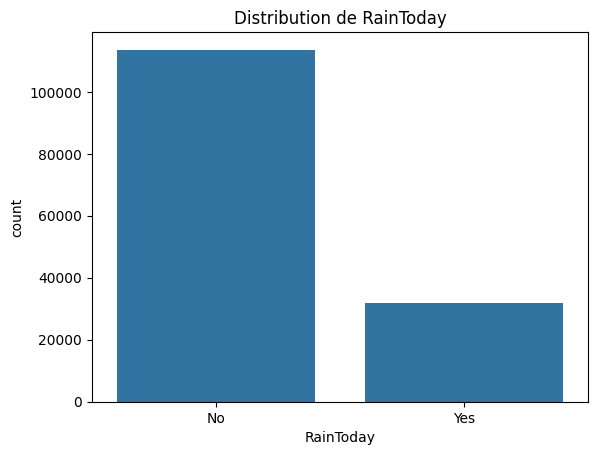

,proportion
RainToday,
No,78.083322
Yes,21.916678


In [30]:
sns.countplot(x='RainToday', data=df)
plt.title("Distribution de RainToday")
plt.show()

df['RainToday'].value_counts(normalize=True)*100

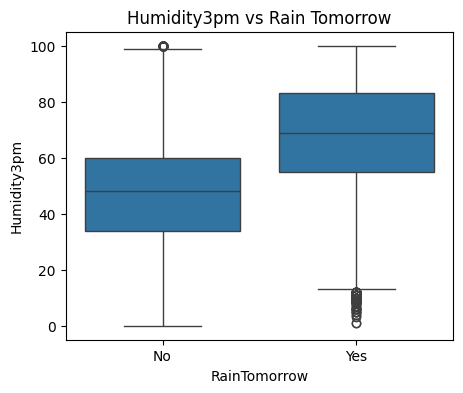

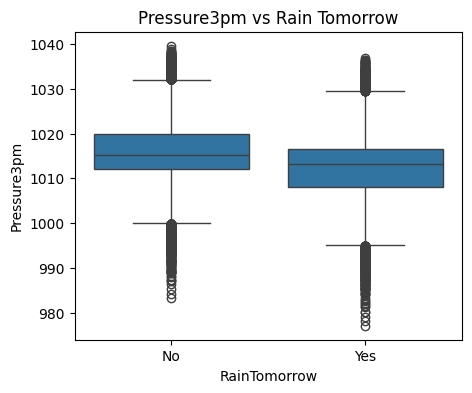

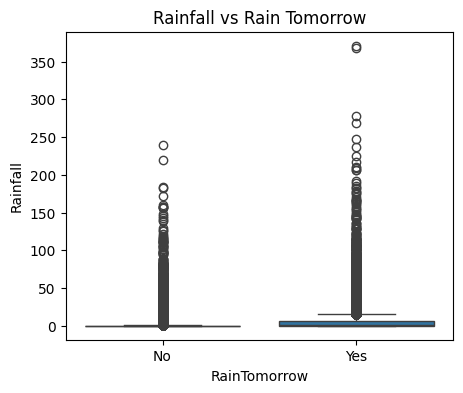

In [35]:
plt.figure(figsize=(5,4))
sns.boxplot(x="RainTomorrow", y="Humidity3pm", data=df)
plt.title("Humidity3pm vs Rain Tomorrow")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(x="RainTomorrow", y="Pressure3pm", data=df)
plt.title("Pressure3pm vs Rain Tomorrow")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(x="RainTomorrow", y="Rainfall", data=df)
plt.title("Rainfall vs Rain Tomorrow")
plt.show()

Les Boxplots montrent qu'il y'en a des valeurs outliers pour la modalite "Yes" peut etre c'est normale. En effet, les jours de pluie forte sont rares et donc éloignés de la médiane, d’où leur position d’outliers dans le boxplot. Cependant pour le "No", ce n'est pas tres coherent de voir un jour non pluie et avoir une la quantite de pluie tomber ce jour la.

In [ ]:
num_vars = df.select_dtypes(include=['int64', 'float64']).columns
for var in num_vars:
    print(f"\nMoyenne de {var} selon RainToday :")
    print(df.groupby('RainToday')[var].mean())


Moyenne de MinTemp selon RainToday :
RainToday
No     12.009982
Yes    12.849575
Name: MinTemp, dtype: float64

Moyenne de MaxTemp selon RainToday :
RainToday
No     24.067912
Yes    20.205211
Name: MaxTemp, dtype: float64

Moyenne de Rainfall selon RainToday :
RainToday
No      0.140846
Yes    10.270354
Name: Rainfall, dtype: float64

Moyenne de Evaporation selon RainToday :
RainToday
No     5.702274
Yes    4.637882
Name: Evaporation, dtype: float64

Moyenne de Sunshine selon RainToday :
RainToday
No     7.950863
Yes    6.398388
Name: Sunshine, dtype: float64

Moyenne de WindGustSpeed selon RainToday :
RainToday
No     39.022946
Yes    43.643265
Name: WindGustSpeed, dtype: float64

Moyenne de WindSpeed9am selon RainToday :
RainToday
No     13.580329
Yes    15.693128
Name: WindSpeed9am, dtype: float64

Moyenne de WindSpeed3pm selon RainToday :
RainToday
No     18.306663
Yes    19.930712
Name: WindSpeed3pm, dtype: float64

Moyenne de Humidity9am selon RainToday :
RainToday
No     65.41

L’analyse bivariée montre que les variables Sunshine, Rainfall, WindGustSpeed et Temp3pm présentent des différences significatives entre les jours de pluie et les jours sans pluie. En particulier, Sunshine apparaît comme la variable la plus discriminante, avec une valeur moyenne nettement plus faible en cas de pluie.

**Corrélation sur le plan Multivariable**

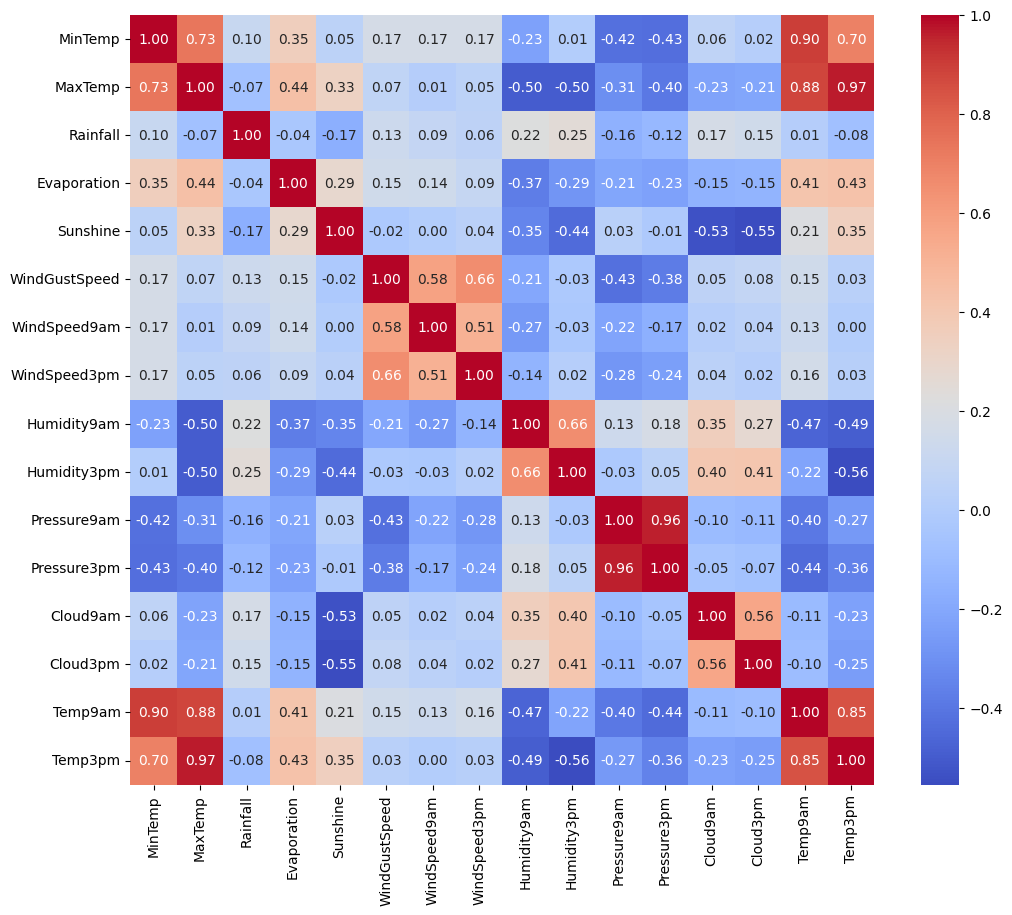

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True,fmt=".2f", cmap="coolwarm")

plt.show()

L’analyse de la matrice de corrélation met en évidence une forte multicolinéarité entre certaines variables, notamment entre les températures (MaxTemp et Temp3pm), ainsi qu’entre les pressions (Pressure9am et Pressure3pm).
Nous constatons que MaxTemp et Temp3pm ($0.978652$) : qu'ils ont une corrélation quasi-parfaite comme on le dit ainsi que Temp9am et MinTemp sont des variables fortement correlées ($0.868983$). En Australie particulierement pour les villes comme Melbourne, MelbourneAirport et Watsonia, la température maximale de la journée survient souvent autour de 15h (Temp3pm). Mathématiquement, ces deux colonnes sont presque des "doublons". Il y'en a d'autres multicolinéarité.
Mais on sait que les algorithmes de boosting sont généralement moins sensibles à la multicolinéarité, surtout lorsqu’ils sont basés sur des arbres (comme Gradient Boosting, XGBoost, LightGBM)

#### Pour les variables categorielles

Les variables catégorielles peuvent être de type "object" ou "int64". Une bonne manière de visualiser les variables catégorielles est d'utiliser des boîtes à moustaches (boxplots).

<Axes: xlabel='Evaporation', ylabel='RainToday'>

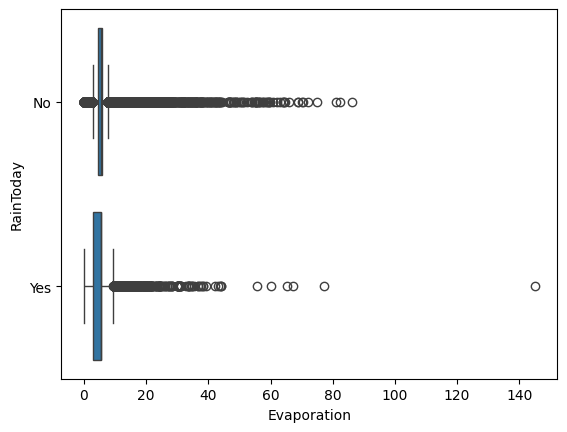

In [ ]:
sns.boxplot(x="Evaporation", y="RainToday", data=df)

Afin d’étudier l’association entre RainToday et RainTomorrow, nous avons appliqué un test du Chi-deux d’indépendance.


**Hypothèse**

H₀ (hypothèse nulle) : RainToday et RainTomorrow sont indépendantes

H₁ : les deux variables sont dépendantes

Règle :

si p-value < 0.05 → on rejette H₀

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['RainTomorrow'], df['RainToday'])

chi2, p, dof, expected = chi2_contingency(table)

if p < 0.05:
    print("Les variables sont dépendantes")
else:
    print("Les variables sont indépendantes")

Les variables sont dépendantes


p-value = 2.755305470762861 × 10⁻⁷⁵

RainToday et RainTomorrow sont fortement associées

Ce qui est logique météorologiquement :

s'il a plu hier,

il y a plus de chances qu'il pleuve aujourd'hui.

In [ ]:
df.describe(include="all")

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,145460,145460,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460,145460.000000,145460,...,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460,145460
unique,3436,49,NaN,NaN,NaN,NaN,NaN,16,NaN,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,2017-04-10,Canberra,NaN,NaN,NaN,NaN,NaN,W,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No
freq,49,3436,NaN,NaN,NaN,NaN,NaN,20241,NaN,22324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113580,113583
mean,NaN,NaN,12.193993,23.221337,2.360898,5.468995,7.610612,NaN,40.035567,NaN,...,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306,NaN,NaN
std,NaN,NaN,6.365750,7.088124,8.382488,3.161541,2.729486,NaN,13.118253,NaN,...,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057,NaN,NaN
min,NaN,NaN,-8.500000,-4.800000,0.000000,0.000000,0.000000,NaN,6.000000,NaN,...,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,NaN,NaN
25%,NaN,NaN,7.700000,18.000000,0.000000,4.000000,7.610000,NaN,31.000000,NaN,...,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000,NaN,NaN
50%,NaN,NaN,12.100000,22.700000,0.000000,5.470000,7.610000,NaN,39.000000,NaN,...,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000,NaN,NaN
75%,NaN,NaN,16.800000,28.200000,1.000000,5.470000,8.700000,NaN,46.000000,NaN,...,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000,NaN,NaN


In [ ]:
#tous les jours ou y a pluie aujourd'hui et demain sur notre zone cible
df3=df[(df['RainToday']=="Yes") & (df['RainTomorrow'] == "Yes") & df.Location.isin(['Melbourne','MelbourneAirport','Watsonia',])]


In [ ]:
df3.describe(include="all")

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,749,749,749.000000,749.000000,749.000000,749.000000,749.000000,749,749.000000,749,...,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749,749
unique,409,3,NaN,NaN,NaN,NaN,NaN,16,NaN,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
top,2010-10-13,Watsonia,NaN,NaN,NaN,NaN,NaN,N,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes
freq,3,296,NaN,NaN,NaN,NaN,NaN,151,NaN,187,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,749,749
mean,NaN,NaN,10.531495,16.839653,8.116689,3.683632,3.333778,NaN,49.415381,NaN,...,83.945634,71.357196,1011.814019,1011.195995,6.393525,6.601696,12.656008,15.051669,NaN,NaN
std,NaN,NaN,4.238524,4.713945,10.243031,2.680781,2.802834,NaN,15.789796,NaN,...,13.192197,16.895801,7.887930,7.910430,1.904837,1.373243,4.107801,4.476243,NaN,NaN
min,NaN,NaN,1.100000,8.400000,1.200000,0.000000,0.000000,NaN,11.000000,NaN,...,41.000000,29.000000,988.900000,988.200000,1.000000,1.000000,3.300000,6.200000,NaN,NaN
25%,NaN,NaN,7.400000,13.500000,2.400000,1.800000,0.500000,NaN,39.000000,NaN,...,74.000000,59.000000,1007.200000,1006.400000,6.000000,6.000000,9.700000,11.900000,NaN,NaN
50%,NaN,NaN,9.600000,15.700000,4.600000,2.800000,3.000000,NaN,48.000000,NaN,...,87.000000,71.000000,1011.900000,1011.400000,7.000000,7.000000,11.900000,13.900000,NaN,NaN
75%,NaN,NaN,13.200000,19.000000,9.600000,5.200000,5.400000,NaN,59.000000,NaN,...,95.000000,85.000000,1017.400000,1016.700000,8.000000,7.000000,15.000000,17.300000,NaN,NaN


La température moyenne à 15h (Temp3pm) les jours de double pluie(pluie aujourd'hui et demain) est de 15.05°C. C'est assez frais, ce qui est cohérent avec un temps pluvieux.

L'humidité moyenne à 9h est de 83.9%, ce qui est très élevé (logique s'il pleut)

La pression moyenne est autour de 1011 hPa, ce qui est proche d'une pression atmosphérique normale, mais légèrement basse (les systèmes dépressionnaires apportent souvent la pluie)

Notons egalement que c'est parce que y'a pluie aujourd'hui qu'il va pleuvoir demain(749)

# **PREPARATION DES DONNEES OU DATA WRANGING**

 #### 1. Identification et gestion des valeurs manquants et valeurs aberrantes s'ils existent

In [ ]:
missing_data = df.isnull()
missing_data.head(5)
#S'il return true cela veut dire que c'est une valeur manquant
#sinon False

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")

Date
Date
False    145460
Name: count, dtype: int64

Location
Location
False    145460
Name: count, dtype: int64

MinTemp
MinTemp
False    145460
Name: count, dtype: int64

MaxTemp
MaxTemp
False    145460
Name: count, dtype: int64

Rainfall
Rainfall
False    145460
Name: count, dtype: int64

Evaporation
Evaporation
False    145460
Name: count, dtype: int64

Sunshine
Sunshine
False    145460
Name: count, dtype: int64

WindGustDir
WindGustDir
False    145460
Name: count, dtype: int64

WindGustSpeed
WindGustSpeed
False    145460
Name: count, dtype: int64

WindDir9am
WindDir9am
False    145460
Name: count, dtype: int64

WindDir3pm
WindDir3pm
False    145460
Name: count, dtype: int64

WindSpeed9am
WindSpeed9am
False    145460
Name: count, dtype: int64

WindSpeed3pm
WindSpeed3pm
False    145460
Name: count, dtype: int64

Humidity9am
Humidity9am
False    145460
Name: count, dtype: int64

Humidity3pm
Humidity3pm
False    145460
Name: count, dtype: int64

Pressure9am
Pressure9am
False    145460

In [ ]:
df.describe(include="all")

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
count,145460,145460,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460,145460.000000,145460,...,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460.000000,145460,145460
unique,3436,49,NaN,NaN,NaN,NaN,NaN,16,NaN,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
top,2017-04-10,Canberra,NaN,NaN,NaN,NaN,NaN,W,NaN,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No
freq,49,3436,NaN,NaN,NaN,NaN,NaN,20241,NaN,22324,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113580,113583
mean,NaN,NaN,12.193993,23.221337,2.360898,5.468995,7.610612,NaN,40.035567,NaN,...,68.880816,51.539143,1017.649946,1015.256314,4.448437,4.509959,16.990624,21.683306,NaN,NaN
std,NaN,NaN,6.365750,7.088124,8.382488,3.161541,2.729486,NaN,13.118253,NaN,...,18.854765,20.471189,6.728467,6.663973,2.265605,2.092954,6.449221,6.850057,NaN,NaN
min,NaN,NaN,-8.500000,-4.800000,0.000000,0.000000,0.000000,NaN,6.000000,NaN,...,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,NaN,NaN
25%,NaN,NaN,7.700000,18.000000,0.000000,4.000000,7.610000,NaN,31.000000,NaN,...,57.000000,37.000000,1013.500000,1011.100000,3.000000,4.000000,12.300000,16.700000,NaN,NaN
50%,NaN,NaN,12.100000,22.700000,0.000000,5.470000,7.610000,NaN,39.000000,NaN,...,69.000000,51.540000,1017.650000,1015.260000,4.450000,4.510000,16.800000,21.400000,NaN,NaN
75%,NaN,NaN,16.800000,28.200000,1.000000,5.470000,8.700000,NaN,46.000000,NaN,...,83.000000,65.000000,1021.800000,1019.400000,6.000000,6.000000,21.500000,26.200000,NaN,NaN


Préparation des données : Sélection et regroupement géographique
L'objectif de cette étape est de spécialiser notre modèle de prédiction météo sur une zone géographique cohérente au lieu de traiter des données provenant de toute l'Australie.
1. Stratégie de regroupement (Clustering)
L'analyse montre que les stations météo de Watsonia et de l'Aéroport de Melbourne sont situées à moins de 20 km du centre de Melbourne.
Hypothèse : Étant donné leur proximité, ces trois localités partagent des systèmes climatiques quasi identiques.
Action : Nous regroupons ces trois points de collecte pour construire un modèle de prédiction localisé.
2. Conservation des micro-variations
Bien que proches, ces lieux peuvent présenter de légères différences (ex: plus de vent à l'aéroport). Pour cette raison, nous conservons la colonne Location comme variable catégorielle. Cela permet au modèle :
De bénéficier d'un volume de données combiné.
D'ajuster ses prédictions en fonction des spécificités de chaque station.
3. Filtrage du Dataset
Le code filtre le DataFrame original pour ne conserver que les lignes correspondant à ces trois lieux.



### Selection de Variable Localisation

In [ ]:
df = df[df.Location.isin(['Melbourne','MelbourneAirport','Watsonia',])]
df.info()
df['Location'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 9211 entries, 54142 to 133392
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9211 non-null   object 
 1   Location       9211 non-null   object 
 2   MinTemp        9211 non-null   float64
 3   MaxTemp        9211 non-null   float64
 4   Rainfall       9211 non-null   float64
 5   Evaporation    9211 non-null   float64
 6   Sunshine       9211 non-null   float64
 7   WindGustDir    9211 non-null   object 
 8   WindGustSpeed  9211 non-null   float64
 9   WindDir9am     9211 non-null   object 
 10  WindDir3pm     9211 non-null   object 
 11  WindSpeed9am   9211 non-null   float64
 12  WindSpeed3pm   9211 non-null   float64
 13  Humidity9am    9211 non-null   float64
 14  Humidity3pm    9211 non-null   float64
 15  Pressure9am    9211 non-null   float64
 16  Pressure3pm    9211 non-null   float64
 17  Cloud9am       9211 non-null   float64
 18  Cloud3p

,count
Location,
Melbourne,3193
MelbourneAirport,3009
Watsonia,3009


On utilise plus ceci pour la Transformer la variable catégorielle en variables quantitatives mais les transformers d'ou ces lignes sont commentees


In [ ]:
#dummy_variable_1=pd.get_dummies(df['Location'], prefix='Location')
#dummy_variable_1.head()

In [ ]:
# fusionner le dataframe "df" et "dummy_variable_1"
#df = pd.concat([df, dummy_variable_1], axis=1) #Ligne a commenter sinon cela
# va concatener a chaque execution

# Supprimer(drop) le colonne d'origine "Location" de "df"
#df.drop("Location", axis = 1, inplace=True)
#df.head()

In [ ]:
df.shape

(9211, 23)

Après filtrage, il reste 9211 enregistrements. Ce volume est jugé suffisant pour entraîner un modèle d'apprentissage automatique robuste. Si la précision s'avère insuffisante, nous pourrions :

Élargir la zone à d'autres villes similaires.



## Coherence sur les donnees

Au lieu de prédire demain, on utilise les données passées pour savoir s'il va pleuvoir aujourd'hui avant de sortir de chez soi. Pour que ce soit plus clair, on renomme les colonnes pour que "la pluie de demain"(RainTomorrow) devienne notre objectif de prédiction pour "aujourd'hui"(RainToday).

In [ ]:
df = df.rename(columns={'RainToday': 'RainYesterday',
                        'RainTomorrow': 'RainToday'
                        })
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday
54142,2008-08-01,Melbourne,9.7,14.7,0.4,3.8,5.2,WSW,80.0,NW,...,70.0,67.0,999.7,1001.5,3.0,7.0,11.8,10.9,No,No
54143,2008-08-13,Melbourne,5.5,13.0,1.6,2.0,8.4,WSW,46.0,W,...,68.0,48.0,1027.1,1025.8,1.0,7.0,7.5,12.6,Yes,No
54144,2008-08-02,Melbourne,8.6,15.3,0.6,3.0,6.0,WSW,46.0,W,...,78.0,55.0,1015.9,1016.1,5.0,6.0,9.8,14.6,No,No
54145,2008-08-03,Melbourne,7.9,14.9,0.0,1.4,5.0,N,52.0,N,...,69.0,54.0,1019.2,1015.7,2.0,4.0,10.0,13.7,No,No
54146,2008-08-04,Melbourne,9.7,13.6,0.2,2.8,1.0,NNE,54.0,N,...,61.0,52.0,1017.7,1018.1,7.0,7.0,11.1,13.4,No,No


## Créer une fonction pour associer les dates aux saisons

 la date brute (ex: 2024-12-25) est difficile à interpréter pour un algorithme. Transformer cette date en Saison (Été, Automne, Hiver, Printemps)
  est une étape cruciale Elle capture la saisonnalité du climat.

In [ ]:
def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer' #Summer Été		Décembre, Janvier, Février
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn' #Automn Autumne (ou Fall)	Mars, Avril, Mai
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'	#Winter Hiver	Juin, Juillet, Août
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring' #Spring Printemps Septembre, Octobre, Novembre


In [ ]:
# On transforme le texte en objet "Date"
df['Date'] = pd.to_datetime(df['Date'])

# On crée la saison
df['Season'] = df['Date'].apply(date_to_season)

#On supprime la date brute qui est devenue inutile
df=df.drop(columns=['Date'])
df

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Season
54142,Melbourne,9.7,14.7,0.4,3.8,5.2,WSW,80.0,NW,WSW,...,67.0,999.7,1001.5,3.0,7.0,11.8,10.9,No,No,Winter
54143,Melbourne,5.5,13.0,1.6,2.0,8.4,WSW,46.0,W,W,...,48.0,1027.1,1025.8,1.0,7.0,7.5,12.6,Yes,No,Winter
54144,Melbourne,8.6,15.3,0.6,3.0,6.0,WSW,46.0,W,WSW,...,55.0,1015.9,1016.1,5.0,6.0,9.8,14.6,No,No,Winter
54145,Melbourne,7.9,14.9,0.0,1.4,5.0,N,52.0,N,N,...,54.0,1019.2,1015.7,2.0,4.0,10.0,13.7,No,No,Winter
54146,Melbourne,9.7,13.6,0.2,2.8,1.0,NNE,54.0,N,NNE,...,52.0,1017.7,1018.1,7.0,7.0,11.1,13.4,No,No,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133388,Watsonia,11.7,16.6,0.4,2.6,0.0,WSW,35.0,WSW,SW,...,78.0,1015.7,1014.6,7.0,8.0,13.9,14.8,No,Yes,Spring
133389,Watsonia,9.9,16.7,1.4,1.4,3.9,SSW,37.0,SW,SW,...,64.0,1016.6,1016.7,5.0,7.0,14.2,15.2,Yes,Yes,Spring
133390,Watsonia,9.6,17.2,6.2,1.6,2.1,SE,44.0,SE,SSE,...,63.0,1016.1,1017.0,7.0,7.0,12.4,15.9,Yes,No,Spring
133391,Watsonia,7.9,13.0,0.0,2.8,3.8,NNW,39.0,N,N,...,69.0,1017.6,1015.3,7.0,7.0,9.0,11.7,No,No,Winter


## Définir les DataFrames de caractéristiques (features) et de cible (target).

In [ ]:
# X contient toutes les variables explicatives (on retire la cible)
X = df.drop(columns='RainToday', axis=1)

# y contient uniquement la variable que l'on veut prédire
y = df['RainToday']

À quel point les classes sont-elles équilibrées ?

In [ ]:
# Si tu travailles sur le dataframe complet :
df['RainToday'].value_counts()

,count
RainToday,
No,7184
Yes,2027


Il ne pleut pas la majorité du temps ; les jours sans pluie sont environ 3,5 fois plus nombreux que les jours de pluie.
Il pleut environ 22% du temps (soit environ 1 jour sur 4 ou 5).

Ceci veut dire que le jeu de données est déséquilibré (imbalanced), car la classe "No" est largement dominante par rapport à la classe "Yes".

## Division du dataset pour l'entrainement et le test avec echantillonage stratifie

On garde 20% des données pour tester le modèle et 80% pour l'entraîner.

La stratification garantit que nous auront la même proportion de "Yes" et de "No" dans le jeu d'entraînement et dans le jeu de test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Définir les transformateurs de prétraitement pour les caractéristiques numériques et catégorielles.

In [ ]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

vérifier les colonnes

In [ ]:
print(f"Variables numériques : {numeric_features}")
print(f"Variables catégorielles : {categorical_features}")

Variables numériques : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Variables catégorielles : ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainYesterday', 'Season']


Les pipelines offrent une flexibilite du code et empeche les fuites de donnees.
Ce qu'on peut faire avec les pipelines

Définir des transformateurs séparés pour les deux types de caractéristiques et les combiner en un seul transformateur de prétraitement unique.

Egalement, les pipelines de données simplifient les étapes de traitement des données. Nous utilisons le module Pipeline pour créer un pipeline. Nous utilisons également StandardScaler comme une étape dans notre pipeline.
Bref on utilise les pipeline pour combiner nos transformeurs.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
Ici, tu crées un objet scaler et tu l’appliques directement sur ton DataFrame.

C’est simple, mais nous on utilise plusieurs transformations ou gérer des colonnes catégorielles en même temps, il faut les coder manuellement.

Definissons une chaine de transformation pour nos variables categorielles et numeriques

In [ ]:
# Standardiser nos variables numeriques
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])#('scaler', MinMaxScaler())

# One-hot encode pour nos variables categorielles
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

Combinaison des transformateurs en un seul transformateur de colonnes de prétraitement unique.

C'est créer une seule machine qui trie et nettoie automatiquement tes "chiffres" et tes "mots" en un seul passage pour que ton modèle reçoive des données parfaite

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['MinTemp', 'MaxTemp', 'Rainfall',
                                  'Evaporation', 'Sunshine', 'WindGustSpeed',
                                  'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
                                  'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                                  'Cloud9am', 'Cloud3pm', 'Temp9am',
                                  'Temp3pm']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Location', 'WindGustDir', 'WindDir9am',
                                  'WindDir3pm', 'RainYesterday', 'Season'])])

# **MODELISATION**

Les forêts aléatoires sont une méthode de bagging(boostrap aggregating) qui entraîne plusieurs arbres de décision sur des ensembles de données bootstrapés. Ces arbres n'ont pas besoin d'être très profonds. L'accent devrait plutôt être mis sur la réduction des biais de prédiction.

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [ ]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'Evaporation',
                                                   'Sunshine', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Cloud9am', 'Cloud3pm',
                                                   'Temp9am', 'Temp3pm']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am', 'WindDir3pm',
                                                   'RainYesterday',
                                                   'Season'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

On ajuste l'hyperparametre classifier:

classifier__n_estimators: nombre d’arbres

classifier__max_depth: profondeur maximale des arbres

classifier__min_samples_split:Nombre minimum d’exemples nécessaires pour diviser un nœud

In [ ]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

On a assemblé le prétraitement et le modèle Random Forest dans un Pipeline pour garantir une transformation des données cohérente et éviter toute fuite d'information (data leakage).

Nous allons ensuite appliqué une Grid Search avec Validation Croisée ($k=5$) pour tester automatiquement différentes combinaisons d'hyperparamètres (nombre d'arbres, profondeur) sur plusieurs échantillons de données.

Cette approche rigoureuse permet de sélectionner le meilleur modèle possible, maximisant ainsi la précision des prédictions de pluie.

Sélectionnons une méthode de validation croisée, en garantissant la stratification de la cible durant la validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True)#Conserver la proportion des classes dans chaque sous-ensemble

Instancions et entraînons GridSearchCV au pipeline.

In [ ]:
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.7s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.7s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.7s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.7s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.7s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   1.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   1.9s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm',
                                                                          'Pressure9am',
                                                                          'Pr...
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Location',
                                                                          'WindGustDir',
                                                                          'WindDir9am',
                                                                          'WindDir3pm',
                                                                          'RainYesterday',
                                                                          'Season'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

Affiche les meilleurs paramètres et le meilleur score de validation croisée.

In [ ]:
print("\nMeilleurs parametres trouves: ", grid_search.best_params_)
print("meilleur score de validation croisée: {:.2f}".format(grid_search.best_score_))


Meilleurs parametres trouves:  {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
meilleur score de validation croisée: 0.86


# **EVALUATION DU MODELE**

Voyons le score estimé de notre modèle.

In [ ]:
test_score = grid_search.score(X_test, y_test)
print("Score de test: {:.2f}".format(test_score))

Score de test: 0.85


Obtenez les prédictions du modèle à partir de l'estimateur de la recherche par grille sur les données non vues.

In [ ]:
y_pred = grid_search.predict(X_test)


Affiche le rapport de classification

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

          No       0.87      0.95      0.91      1437
         Yes       0.74      0.48      0.58       406

    accuracy                           0.85      1843
   macro avg       0.80      0.71      0.74      1843
weighted avg       0.84      0.85      0.83      1843



Affiche la matrice de confusion.

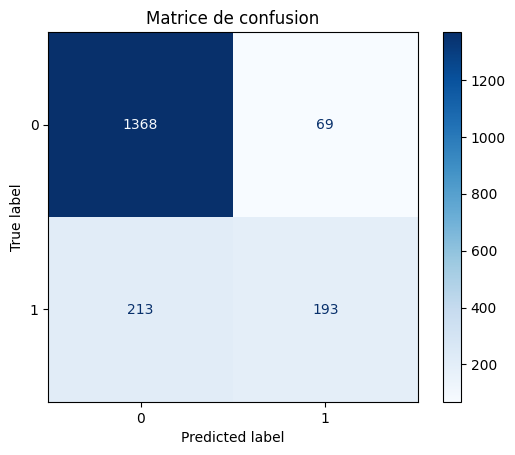

In [ ]:
matrice_de_conf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrice_de_conf)
disp.plot(cmap='Blues')
plt.title('Matrice de confusion')
plt.show()

Prediction de pluie et que y'a bien pluie on 1368

Prediction de non pluie et que y'en a pas plus realite nous avons 193

Le modele dit que non pluie alors qu'en realite y'a pluie 69

Prediction de pluie alors que en realite y'en a pas pluie 213

Top des variables les plus importantes pour prédire la pluie aujourd’hui

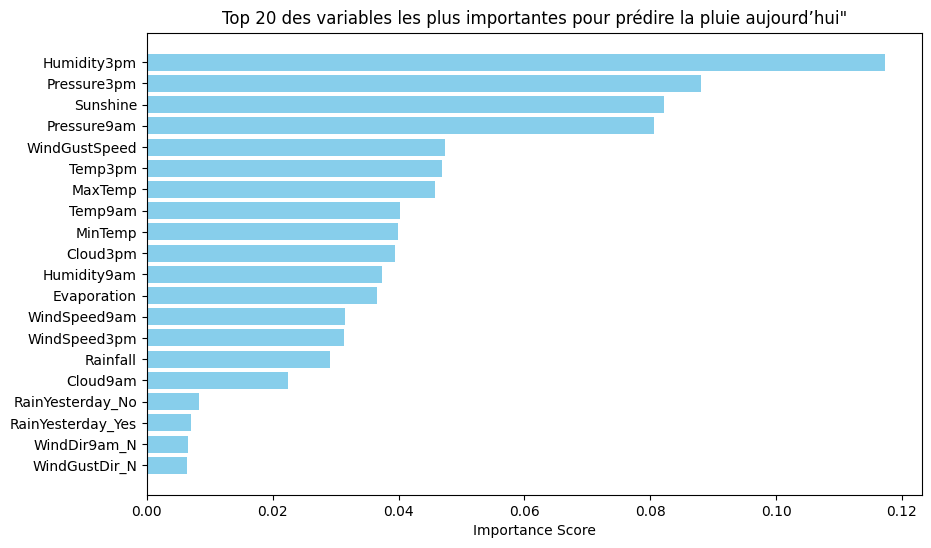

In [ ]:
# Combine numeric and categorical feature names
feature_names = numeric_features + list(grid_search.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

N = 20  # Change this number to display more or fewer features
top_features = importance_df.head(N)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.title(f'Top {N} des variables les plus importantes pour prédire la pluie aujourd’hui"')
plt.xlabel('Importance Score')
plt.show()

Essayons de modeliser avec la regression logistique afin de voir sa performance par rapport au RandomForest

In [ ]:
# 1. Remplacer RandomForest par LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42, max_iter=1000))

# 2. Mettre à jour l’estimateur dans GridSearchCV
grid_search.estimator = pipeline

# 3. Nouvelle grille de paramètres pour Logistic Regression
param_grid = {
    'classifier__solver': ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

grid_search.param_grid = param_grid

#  4. Entraîner avec les nouvelles configurations
model = grid_search.fit(X_train, y_train)

#  5. Prédictions
y_pred = model.predict(X_test)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.3s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.3s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.3s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.2s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.2s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.1s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.1s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.1s
[CV] END classifier__class_weight=No

In [ ]:
model

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'Evaporation',
                                                                          'Sunshine',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm',
                                                                          'Pressure9am',
                                                                          'Pr...
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Location',
                                                                          'WindGustDir',
                                                                          'WindDir9am',
                                                                          'WindDir3pm',
                                                                          'RainYesterday',
                                                                          'Season'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             param_grid={'classifier__class_weight': [None, 'balanced'],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear']},
             scoring='accuracy', verbose=2)


Rapport classification:
              precision    recall  f1-score   support

          No       0.86      0.94      0.90      1437
         Yes       0.67      0.44      0.53       406

    accuracy                           0.83      1843
   macro avg       0.76      0.69      0.71      1843
weighted avg       0.81      0.83      0.82      1843



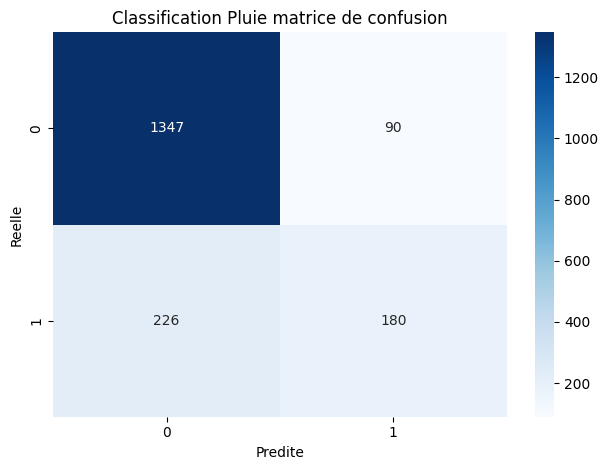

In [ ]:
print("\nRapport classification:")
print(classification_report(y_test, y_pred))

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels
plt.title('Classification Pluie matrice de confusion')
plt.xlabel('Predite')
plt.ylabel('Reelle')

# Show the plot
plt.tight_layout()
plt.show()

Comparaison des deux modeles

Prediction de pluie et que y'a bien pluie on 1347 avec GradientBoosting Modele on avait 1368

Prediction de non pluie et que y'en a pas pluie en realite 180 avec GradientBoosting Modele on avait 193

Le modele dit que non pluie alors qu'en realite y'a pluie 90 avec GradientBoosting Modele on avait 69

Prediction de pluie alors qu'en realite y'en a pas pluie 226 avec GradientBoosting Modele on avait 213

ROC AUC: 0.84


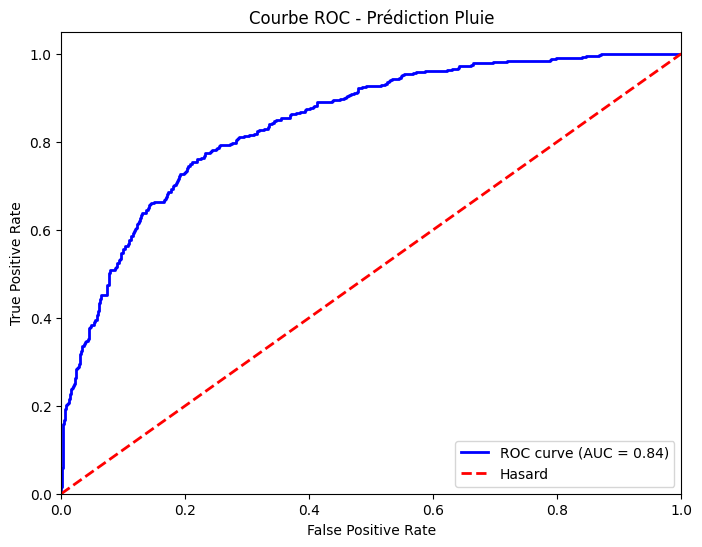

In [ ]:
import matplotlib.pyplot as plt

# 1. Probabilités pour la classe positive ("Yes" ou 1)
y_prob = model.predict_proba(X_test)[:, 1]  # colonne 1 = probabilité de "Yes"

# 2. Calculer la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label='Yes')
roc_auc = auc(fpr, tpr)
print("ROC AUC: {:.2f}".format(roc_auc))


# 3. Afficher la courbe ROC
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Hasard')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC - Prédiction Pluie')
plt.legend(loc="lower right")
plt.show()

La courbe ROC montre que le modèle LogisticRegression distingue efficacement les jours de pluie des jours sans pluie, avec une AUC de 0.84, indiquant une bonne capacité prédictive globale.

# INTERPRETATION

Voyons si notre modele generalise ne fait pas overfitting en comparant les score d'entrainement et de test

In [ ]:
best_model = grid_search.best_estimator_  # Pipeline avec les meilleurs params
train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)
print("Score d'entrainement: {:.2f}".format(train_score))
print("Score de test : {:.2f}".format(test_score))

Score d'entrainement: 0.85
Score de test : 0.83


Ces deux score proche donc notre ne memorise pas les resultats d'entrainement

Comparaison des deux modeles

| Metric          | Gradient Boosting | Régression Logistique |
| --------------- | ----------------- | --------------------- |
| Accuracy        | 0.85              | 0.83                  |
| Precision (No)  | 0.87              | 0.86                  |
| Recall (No)     | 0.95              | 0.94                  |
| Precision (Yes) | 0.74              | 0.67                  |
| Recall (Yes)    | 0.48              | 0.44                  |
| F1 (Yes)        | 0.58              | 0.53                  |


Accuracy(Performance globale du
modele) : GB légèrement meilleure (0.85 vs 0.83)

Précision ou A quel point les
predictions pluie
sont precises : GB meilleure (0.74 vs 0.67) quand il prédit pluie, c’est plus fiable.

Recall pour "Yes" : GB meilleure (0.48 vs 0.44)  il détecte plus de jours de pluie réels.

F1 pour "Yes" : GB meilleure (0.58 vs 0.53)  meilleur compromis précision/recall pour la classe pluie.


En résumé : Gradient Boosting est meilleur pour détecter la pluie, tandis que la régression logistique est un peu plus simple mais légèrement moins performante sur la classe minoritaire ("Yes").

## Interpretation General

Le modèle Gradient Boosting présente de meilleures performances globales que la régression logistique, notamment en termes d’accuracy.
Il est également plus efficace pour prédire et détecter les jours de pluie, avec de meilleurs scores de précision, recall et F1 pour la classe “Yes”.
Ainsi, il constitue un meilleur choix pour ce problème, surtout pour la détection de la pluie qui est la classe minoritaire.